# **Test Preprocessing, Tokenization, and Sequence Padding**

# 1. Load the dataset

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/sem6AI/hatevsoffensive_language.csv")

In [24]:
df.head()

,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


**Deleting rows that contain empty values**

In [25]:
data_cleaning = df["text"].dropna()

In [26]:
data_cleaning[0]

"!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out..."

# 2. Clean the Text

**Lower Order**

In [27]:
def lower_order(text):
  """
  This function converts all the text in input text to lower order.
  Input Args:
  token_text : input text.
  Returns:
  small_order_text : text converted to small/lower order.
  """
  small_order_text = text.lower()
  return small_order_text

# Test:
sample_text = "This Is some Normalized TEXT"
sample_small = lower_order(sample_text)
print(sample_small)


this is some normalized text


**Remove URLs**

In [28]:
import re
def remove_urls(text):
  """
  This function will try to remove URL present in out dataset and replace it with space using regex library.
  Input Args:
  text: strings of text that may contain URLs.
  Output Args:
  text: URLs replaces with text
  """
  url_pattern = re.compile(r'https?://\S+|www\.\S+')
  return url_pattern.sub(r'', text)


**Remove Emojis**

In [29]:
def remove_emoji(string):
  """
  This function will replace the emoji in string with whitespace
  """
  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r' ', string)

**Remove Unwanted Characters**

In [30]:
def removeunwanted_characters(document):
  """
  This function will remove all the unwanted characters from the input dataset.
  Input Args:
  documet: A text data to be cleaned.
  Return:
  A cleaned document.
  """
  # remove user mentions
  document = re.sub("@[A-Za-z0-9_]+"," ", document)
  # remove hashtags
  document = re.sub("#[A-Za-z0-9_]+","", document)
  # remove punctuation
  document = re.sub("[^0-9A-Za-z ]", "" , document)
  #remove emojis
  document = remove_emoji(document)
  # remove double spaces
  document = document.replace('  ',"")
  return document.strip()       # Removes extra spaces from the start and end of a string.

**Remove Stop Words**

In [31]:
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stop_words = set(stopwords.words('english'))
custom_stopwords = ['@', 'RT']
stop_words.update(custom_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
def remove_stopwords(text_tokens):
  """
  This function removes all the stopwords present in out text tokens.
  Input Args:
  text_tokens: tokenize input of our datasets.
  Returns:
  result_tokens: list of token without stopword.
  """

  result_tokens = []
  for token in text_tokens:
    if token not in stop_words:
       result_tokens.append(token)
  return result_tokens

**Handle Contractions**

In [33]:
# pip install contractions

In [34]:
import contractions

def expand_contractions(text):
    """
    Expands contractions in raw text (string level)
    """
    return contractions.fix(text)

text = "I don't like it because it's boring"
print(expand_contractions(text))

I do not like it because it is boring


**Lemmatization**

In [35]:
from nltk.stem import WordNetLemmatizer #tool that converts words to their base form
from nltk import word_tokenize,pos_tag #assigns grammar labels (verb, noun etc.)
nltk.download('averaged_perceptron_tagger') #model that detects parts of speech (POS)
nltk.download('wordnet') #dictionary of words + meanings (used for lemmatization)

def lemmatization(token_text):
  """
  This function performs the lemmatization operations as explained above.
  Input Args:
  token_text: list of tokens.
  Returns:
  lemmatized_tokens: list of lemmatized tokens.
  """
  lemma_tokens = []
  wordnet = WordNetLemmatizer()
  lemmatized_tokens = [wordnet.lemmatize(token, pos = 'v') for token in token_text]

  return lemmatized_tokens

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Tokenization**

In [36]:
import nltk #the main NLP library (toolbox)
nltk.download('punkt_tab')  #punkt provides the rules/data needed to split text properly
from nltk import word_tokenize #worker (function that uses the rules of punkt)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [37]:
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

def text_cleaning_pipeline(text, rule="lemmatize"):

    wordnet = WordNetLemmatizer()
    porter = PorterStemmer()

    text = lower_order(text)
    text = remove_urls(text)
    text = remove_emoji(text)
    text = removeunwanted_characters(text)
    text = expand_contractions(text)

    return text

In [38]:
df["cleaned_text"] = df["text"].apply(text_cleaning_pipeline)

In [39]:
df.head()

,label,text,cleaned_text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you should not complain about cl...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat ho...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she start...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true or...


#3. Visualize the cleaned data

**Visual Summary of the dataset using Word Cloud**

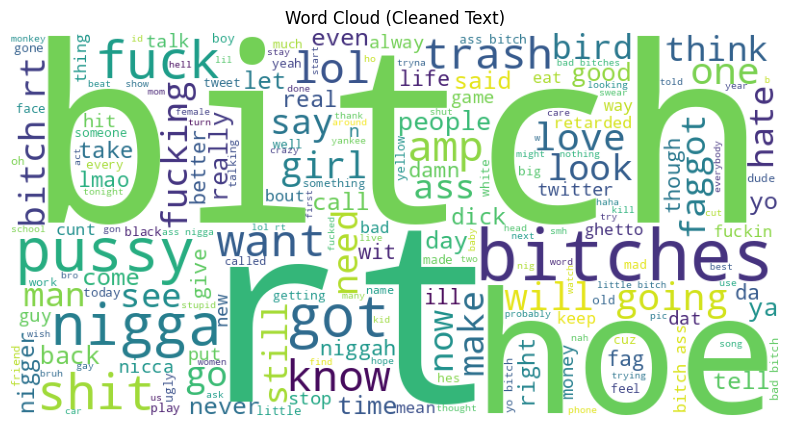

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["cleaned_text"])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud (Cleaned Text)")
plt.show()

**Display most frequent words**

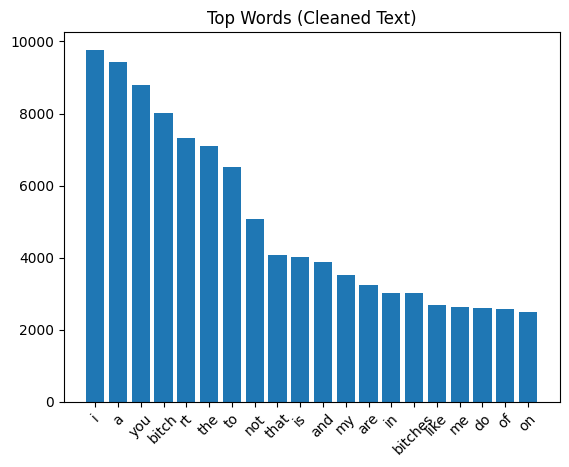

In [41]:
from collections import Counter
import matplotlib.pyplot as plt

all_words = " ".join(df["cleaned_text"]).split()

counter = Counter(all_words)
common = counter.most_common(20)

words = [w[0] for w in common]
counts = [w[1] for w in common]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Words (Cleaned Text)")
plt.show()

# 4. Tokenization and Padding

**Train-test split**

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

**Keras Tokenizer to convert the text into sequences of integers**

In [43]:
# !pip uninstall -y jax jaxlib

In [44]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

**Percentile-based padding**

In [45]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

lengths = [len(seq) for seq in X_train_seq]

max_len = int(np.percentile(lengths, 95))  # keep 95% of sequences
print("Chosen max_len:", max_len)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

Chosen max_len: 26


# **Model Building and Training**

# Model 1: Simple RNN with a trainable Embedding layer

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

num_classes = 3
vocab_size = 10000
embedding_dim = 128

model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),

    SimpleRNN(128),

    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Model 2: LSTM with a trainable Embedding layer

In [80]:
from tensorflow.keras.layers import LSTM

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),

    LSTM(128),

    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Model 3: LSTM with a pretrained Word2Vec embeddings

**Load Word2Vec**

In [48]:
# !pip install numpy==1.23.5
# !pip install gensim

  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Using cached jax-0.4.13-py3-none-any.whl
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
optax 0.2.8 requires jaxlib>=0.5.3, which is not installed.
flax 0.11.2 requires jax>=0.6.0, but you have jax 0

In [49]:
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


**Build Embedding Matrix**

In [83]:
import numpy as np

embedding_dim = 50
vocab_size = 10000

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]

**Embedding Layer (NON-trainable)**

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model3 = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),

    LSTM(64),

    Dense(num_classes, activation='softmax')
])

# **Model Training and Evaluation**

# 1. Compile (for all models)

**Loss, Optimizer, Metrics**

In [75]:
loss_fn = 'sparse_categorical_crossentropy'
optimizer = 'adam'
metrics_list = ['accuracy']

**Model 1 (RNN)**

In [76]:
model1.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=metrics_list
)

**Model 2 (LSTM)**

In [81]:
model2.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=metrics_list
)

**Model 3 (LSTM + Word2Vec)**

In [85]:
model3.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=metrics_list
)

# 2. Early Stopping Callback

In [78]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

**Convert labels to Numpy + numeric type**

In [58]:
print(type(X_train_pad))
print(X_train_pad.dtype)
print(type(y_train))
print(y_train.dtype)

<class 'numpy.ndarray'>
int32
<class 'pandas.core.series.Series'>
object


In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [60]:
import numpy as np

y_train = np.array(y_train).astype("float32")
y_test = np.array(y_test).astype("float32")

In [61]:
print(type(X_train_pad))
print(X_train_pad.dtype)
print(type(y_train))
print(y_train.dtype)

<class 'numpy.ndarray'>
int32
<class 'numpy.ndarray'>
float32


In [63]:
np.unique(y_train)

array([0., 1., 2.], dtype=float32)

# 3. Train the Models

**Model 1**

In [79]:
history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.7738 - loss: 0.6736 - val_accuracy: 0.7730 - val_loss: 0.6665
Epoch 2/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.7702 - loss: 0.6452 - val_accuracy: 0.7912 - val_loss: 0.5646
Epoch 3/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.7889 - loss: 0.5726 - val_accuracy: 0.7755 - val_loss: 0.5736
Epoch 4/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7776 - loss: 0.5797 - val_accuracy: 0.7730 - val_loss: 0.6007
Epoch 5/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.7774 - loss: 0.5807 - val_accuracy: 0.7730 - val_loss: 0.6784
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


**Model 2**

In [82]:
history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.8494 - loss: 0.4356 - val_accuracy: 0.8848 - val_loss: 0.3352
Epoch 2/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.9059 - loss: 0.2892 - val_accuracy: 0.8901 - val_loss: 0.3279
Epoch 3/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.9180 - loss: 0.2383 - val_accuracy: 0.8751 - val_loss: 0.3552
Epoch 4/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.9331 - loss: 0.1942 - val_accuracy: 0.8808 - val_loss: 0.3475
Epoch 5/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.9484 - loss: 0.1491 - val_accuracy: 0.8711 - val_loss: 0.4204
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [72]:
print(len(history1.history['loss']))

3


**Model 3**

In [87]:
history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8649 - loss: 0.3648 - val_accuracy: 0.8695 - val_loss: 0.3491
Epoch 2/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8732 - loss: 0.3319 - val_accuracy: 0.8745 - val_loss: 0.3310
Epoch 3/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8833 - loss: 0.3100 - val_accuracy: 0.8747 - val_loss: 0.3246
Epoch 4/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8861 - loss: 0.2994 - val_accuracy: 0.8759 - val_loss: 0.3303
Epoch 5/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8917 - loss: 0.2860 - val_accuracy: 0.8715 - val_loss: 0.3273
Epoch 6/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8968 - loss: 0.2763 - val_accuracy: 0.8735 - val_loss: 0.3317
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


# 4. Visualization

**Loss + Accuracy curves**

In [94]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator # <--- Import this

def plot_history_side_by_side(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy plot
    ax[0].plot(history.history['accuracy'], label='Train Accuracy')
    ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    ax[0].set_title(title + " - Accuracy")
    ax[0].xaxis.set_major_locator(MaxNLocator(integer=True)) # <--- Force integers
    ax[0].legend()

    # Loss plot
    ax[1].plot(history.history['loss'], label='Train Loss')
    ax[1].plot(history.history['val_loss'], label='Val Loss')
    ax[1].set_title(title + " - Loss")
    ax[1].xaxis.set_major_locator(MaxNLocator(integer=True)) # <--- Force integers
    ax[1].legend()

    plt.tight_layout()
    plt.show()

**Model 1**

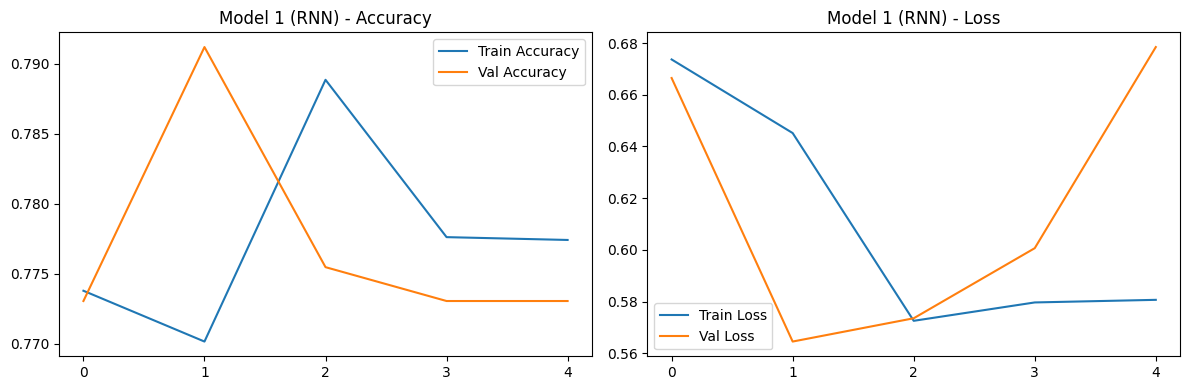

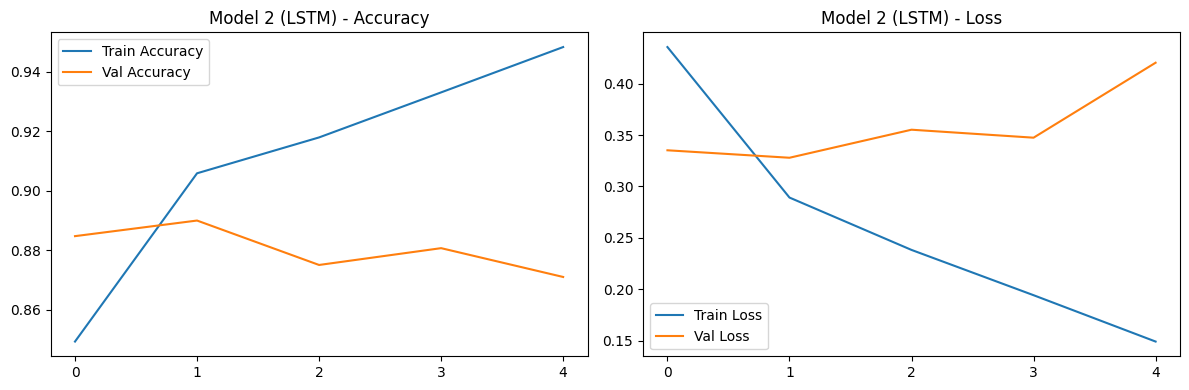

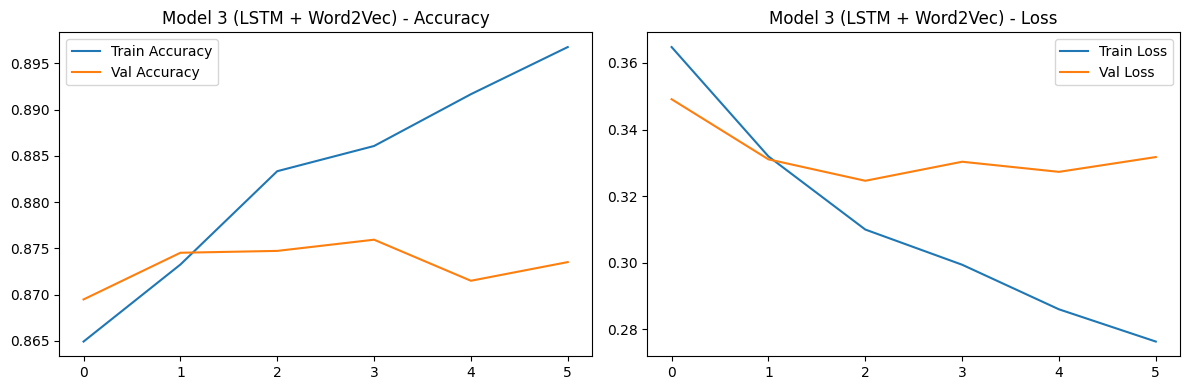

In [96]:
plot_history_side_by_side(history1, "Model 1 (RNN)")
plot_history_side_by_side(history2, "Model 2 (LSTM)")
plot_history_side_by_side(history3, "Model 3 (LSTM + Word2Vec)")

# 5. Predictions

In [97]:
y_pred1 = np.argmax(model1.predict(X_test_pad), axis=1)
y_pred2 = np.argmax(model2.predict(X_test_pad), axis=1)
y_pred3 = np.argmax(model3.predict(X_test_pad), axis=1)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


**Test Accuracy + Loss**

In [103]:
test_loss1, test_acc1 = model1.evaluate(X_test_pad, y_test, verbose=0)
test_loss2, test_acc2 = model2.evaluate(X_test_pad, y_test, verbose=0)
test_loss3, test_acc3 = model3.evaluate(X_test_pad, y_test, verbose=0)

print("Model 1 (RNN) → Loss:", test_loss1, "Accuracy:", test_acc1)
print("Model 2 (LSTM) → Loss:", test_loss2, "Accuracy:", test_acc2)
print("Model 3 (Word2Vec + LSTM) → Loss:", test_loss3, "Accuracy:", test_acc3)

Model 1 (RNN) → Loss: 0.5645958781242371 Accuracy: 0.7912043333053589
Model 2 (LSTM) → Loss: 0.32793575525283813 Accuracy: 0.89005446434021
Model 3 (Word2Vec + LSTM) → Loss: 0.3246009945869446 Accuracy: 0.8747225999832153


# 6. Confusion Matrix

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

**Model 1**

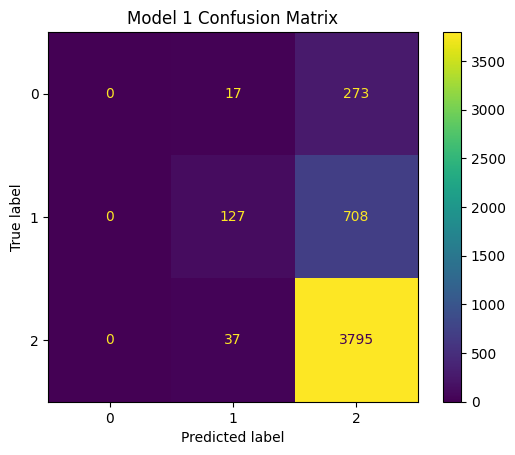

In [99]:
cm1 = confusion_matrix(y_test, y_pred1)
ConfusionMatrixDisplay(cm1).plot()
plt.title("Model 1 Confusion Matrix")
plt.show()

Model 2

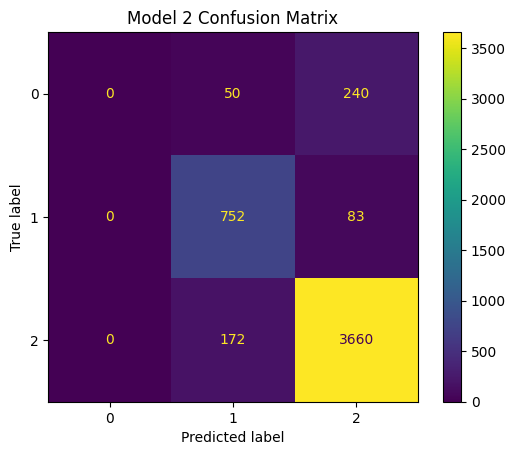

In [100]:
cm2 = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm2).plot()
plt.title("Model 2 Confusion Matrix")
plt.show()

**Model 3**

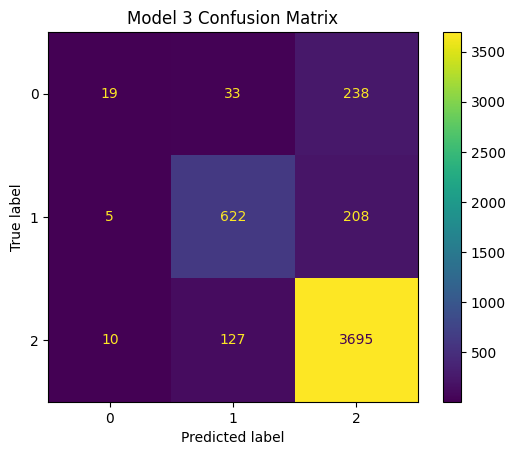

In [101]:
cm3 = confusion_matrix(y_test, y_pred3)
ConfusionMatrixDisplay(cm3).plot()
plt.title("Model 3 Confusion Matrix")
plt.show()

# 7. Classification Report

In [102]:
from sklearn.metrics import classification_report

print("Model 1 Report:\n", classification_report(y_test, y_pred1))
print("Model 2 Report:\n", classification_report(y_test, y_pred2))
print("Model 3 Report:\n", classification_report(y_test, y_pred3))

Model 1 Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       290
         1.0       0.70      0.15      0.25       835
         2.0       0.79      0.99      0.88      3832

    accuracy                           0.79      4957
   macro avg       0.50      0.38      0.38      4957
weighted avg       0.73      0.79      0.72      4957

Model 2 Report:
               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       290
         1.0       0.77      0.90      0.83       835
         2.0       0.92      0.96      0.94      3832

    accuracy                           0.89      4957
   macro avg       0.56      0.62      0.59      4957
weighted avg       0.84      0.89      0.86      4957

Model 3 Report:
               precision    recall  f1-score   support

         0.0       0.56      0.07      0.12       290
         1.0       0.80      0.74      0.77       835
         2.0       0.89 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# **Error Analysis**

# 1. Analyze misclassified examples

In [106]:
import numpy as np

X_test = np.array(X_test)
y_test = np.array(y_test)

In [110]:
df["label"]
print(df["label"].unique())

class_names = {
    0: "neither",
    1: "offensive language",
    2: "hate speec"
}

['neither' 'offensive language' 'hate speec']


In [145]:
def show_errors(X_test, y_test, y_pred, model_name):
    wrong_idx = np.where(y_test != y_pred)[0]

    print(f"\n{model_name} Misclassified Examples")
    print("-"*50)

    for i in wrong_idx[:3]:
        print("Text:", X_test[i])

        print("True Label:", class_names[int(y_test[i])])
        print("Predicted Label:", class_names[int(y_pred[i])])
        print("\n")



In [146]:
y_test = np.array(y_test).astype(int)

In [147]:
show_errors(X_test, y_test, y_pred1, "RNN Model")
show_errors(X_test, y_test, y_pred2, "LSTM Model")
show_errors(X_test, y_test, y_pred3, "Word2Vec + LSTM Model")


RNN Model Misclassified Examples
--------------------------------------------------
Text: rt lol my credit are not no where near goodbut i know the right man for the jobthat ho nice though
True Label: offensive language
Predicted Label: hate speec


Text: what did you search gay redneck episode 1 play
True Label: neither
Predicted Label: hate speec


Text: got to love it when the islamofascist cow tries to make a retort about age typical muzzie idiocy
True Label: neither
Predicted Label: hate speec



LSTM Model Misclassified Examples
--------------------------------------------------
Text: what did you search gay redneck episode 1 play
True Label: neither
Predicted Label: offensive language


Text: got to love it when the islamofascist cow tries to make a retort about age typical muzzie idiocy
True Label: neither
Predicted Label: offensive language


Text: i am just tryna get to sleep before the birds start getting rowdy
True Label: offensive language
Predicted Label: hate speec



W

# 2. Model Complexity vs. Performance Evaluation

RNN: The RNN has the simplest architecture, but it performs poorly in terms of balanced classification. It heavily favors the majority class and fails to generalize well to minority classes due to limited memory and weak contextual understanding.


LSTM: The LSTM model provides the best overall accuracy. Its memory gates allow it to capture long-term dependencies effectively, resulting in strong classification performance across major classes. However, it still struggles with minority class prediction.

LSTM + Word2Vec: Although this model is the most complex, it does not achieve the highest accuracy. However, it provides the best macro F1-score, indicating improved class balance. The pretrained embeddings enhance semantic understanding but may introduce slight domain mismatch.

# 3. Error Analysis



1. The models show a strong bias towards predicting “hate speech” or “offensive language” for most inputs, including neutral sentences.

2. Even simple neutral text such as “I love cats” is incorrectly classified as toxic, indicating poor generalization to unseen or non-toxic patterns.

3. This behavior is likely due to dataset imbalance, where toxic samples dominate the training data. As a result, the model becomes biased toward majority classes (offensive/hate speech).

4. There is significant class overlap between “offensive language” and “hate speech”, which makes it difficult for the model to learn clear decision boundaries between them.

5. The models may also be overfitting to toxic keywords, rather than learning true semantic meaning, leading to false positives on neutral sentences.

# 4. Potential Improvements

1. Handle class imbalance: Use class weights or resampling techniques to balance neutral, offensive, and hate speech classes, reducing bias toward majority classes.

2. Improve word embeddings: Use pretrained embeddings like FastText or GloVe and fine-tune them to improve semantic understanding of words.

3. Use Bidirectional LSTM: Process text in both forward and backward directions to improve context understanding and reduce misclassification.

4. Improve preprocessing pipeline: Properly handle slang, emojis, and contractions while avoiding over-cleaning to preserve meaning.

5. Reduce overfitting: Apply Dropout, L2 regularization, and EarlyStopping to improve generalization on unseen data.

6. Improve dataset quality: Remove noisy labels and clearly define boundaries between offensive language and hate speech to reduce confusion.

7. Use advanced models (future work): Adopt Transformer-based models like BERT for better contextual and semantic understanding.


In [149]:
# !pip install gradio

# **GUI for Real Time Prediction**

In [150]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

class_names = ['neither', 'offensive language', 'hate speech']

max_len = 100

def predict(tweet, model_name):

    model = {
        "RNN": model1,
        "LSTM": model2,
        "Word2Vec + LSTM": model3
    }[model_name]

    seq = tokenizer.texts_to_sequences([tweet])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model.predict(padded)
    label = np.argmax(pred, axis=1)[0]

    return class_names[label]


interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Textbox(label="Enter Tweet"),
        gr.Dropdown(["RNN", "LSTM", "Word2Vec + LSTM"], label="Choose Model")
    ],
    outputs="text"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b5f74079ee4fa11682.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
